# Project 1

## Domain and parameters

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy as sp
from scipy.sparse import spdiags
import matplotlib.patheffects as pe

import utils
%reload_ext autoreload
%autoreload 2

In [2]:
# diffusion coefficient
a = 0.005

# domain
Nx = 50
Ny = 50
L = 1
ix = np.linspace(1, Nx, Nx)  
iy = np.linspace(1, Ny, Ny)
x = ix/(Nx+1)
y = iy/(Ny+1)

# meshgrid
[Y, X] = np.meshgrid(y, x) 

# source term
k = 0.02 * np.exp(-((X-0.7)**2/0.09 + (Y-0.6)**2/0.25))
k_flat = k.reshape(-1, order='F')

# indexing
dx = x[1] - x[0]
dy = y[1] - y[0]
dt = 0.01
index = np.arange(0, Nx * Ny).reshape((Nx, Ny), order='F')

# boundary conditions
BCL_D = 0.5 - 0.5 * np.cos(2 * np.pi * y)
BCR_N = np.zeros(len(y))
BCB_N = -0.3 * np.ones(len(x))
BCT_D = 0.5 + 0.5 * np.sin(4*np.pi * x - 0.5*np.pi)

## Set Up Problem

In [3]:
LHS = lambda u: -a * utils.Laplace_u(u, Nx, Ny, index, dx, dy)

LBC = utils.Laplace_BC(Nx, Ny, index, dx, dy, BCL_D, BCR_N, BCB_N, BCT_D)

RHS = k_flat + a*LBC

## Steady State Solution 

In [4]:
x0 = np.zeros(Nx * Ny)
tol = 1e-8
maxit = 5000

In [5]:
[U, iter, resvec] = utils.cg_solver(LHS, RHS, x0, tol, maxit)
print(f'CG converged in {iter} iterations with final residual {resvec[-1]:.2e}')

CG converged in 182 iterations with final residual 8.04e-09


In [6]:
U_ss = U.reshape(Nx, Ny).T

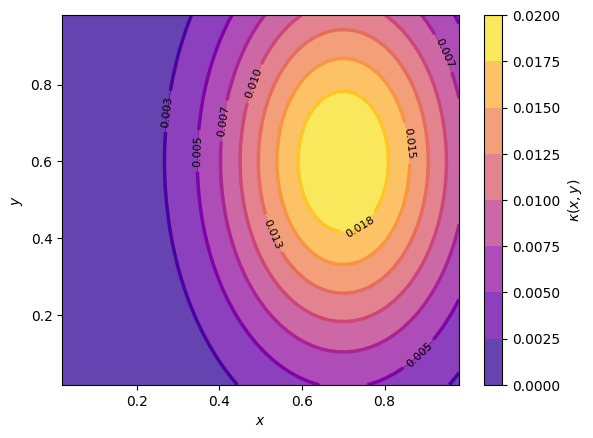

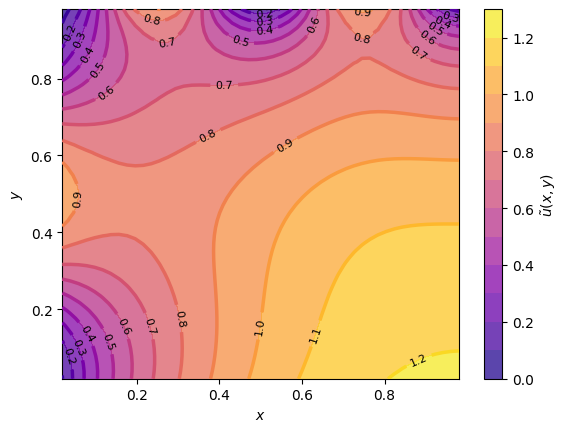

In [7]:
utils.plot_source_and_steady_state(X, Y, k, U_ss)

## Heat Equation

In [8]:
dt = 0.1
alpha = a

history, time_stop = utils.crank_nicolson(
    Nx, Ny, index, dx, dy, dt, alpha, k_flat, U_ss,
    BCL_D, BCR_N, BCB_N, BCT_D,
    u0=None
)

Converged at t = 362.8000 (3628 timesteps)


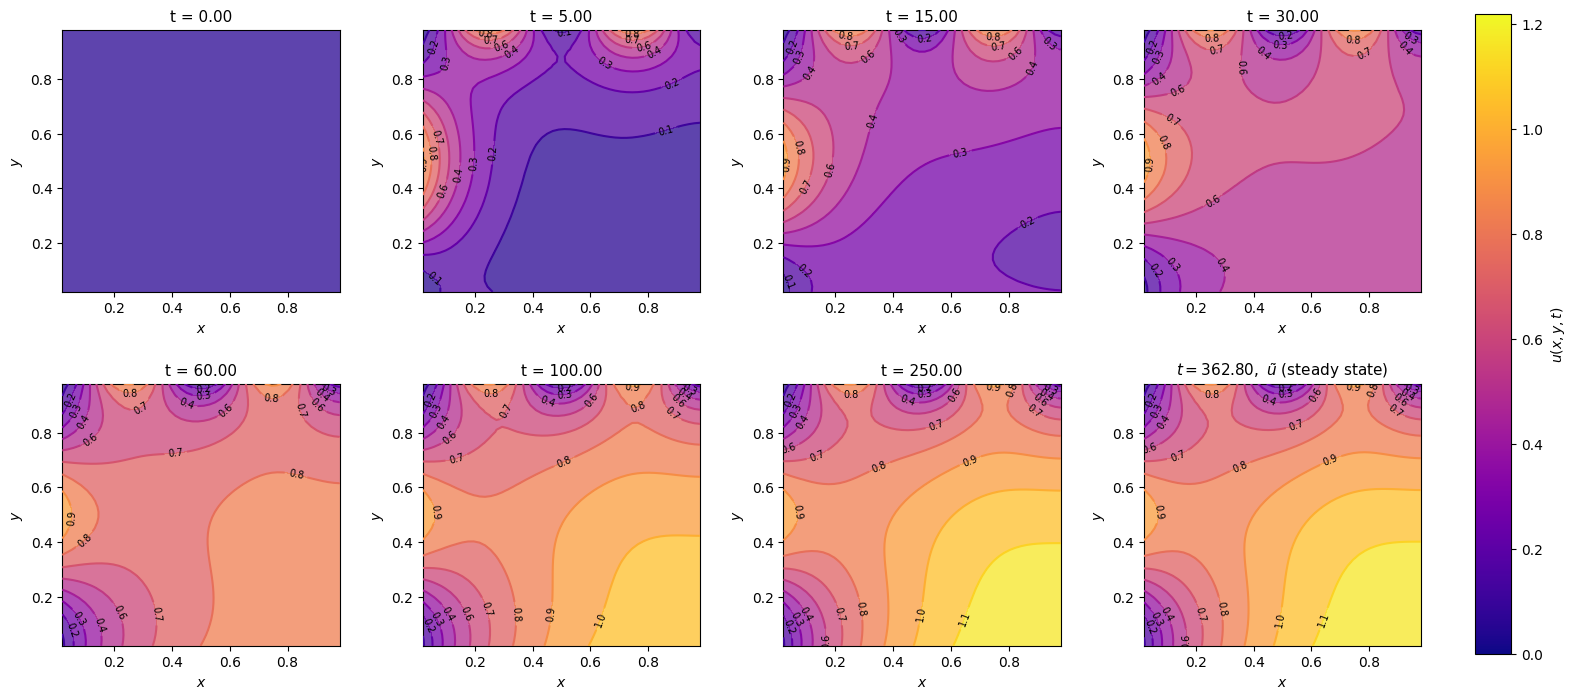

In [9]:
utils.plot_transient_timesteps(X, Y, history)

Animation saved!


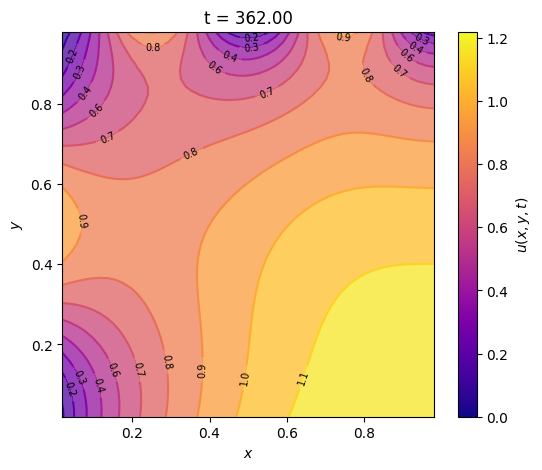

In [10]:
utils.generate_animation(X, Y, history)